## CAT AND DOG

### Yêu cầu
- Phân tích dữ liệu 
- Cân bằng dữ liệu
- Xây dựng mô hình CNN thuần bằng PyTorch
- Huấn luyện và đánh giá mô hình
- Hạn chế overfitting

In [1]:
import os
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

## 1. Chuẩn bị dữ liệu Cat and Dog

In [21]:
# Đường dẫn đến thư mục dataset
dataset_path = './data/cat_dog'

if not os.path.exists(dataset_path):
    print("Chưa tìm thấy dataset.")
else:
    print("Đã tìm thấy thư mục data:", dataset_path)

Đã tìm thấy thư mục data: ./data/cat_dog


In [5]:
# Transform cơ bản để đọc dữ liệu gốc phục vụ phân tích dữ liệu
base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

if os.path.exists(dataset_path):
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=base_transform)
    classes = full_dataset.classes
    print("Các lớp dữ liệu:", classes)
    print("Tổng số ảnh:", len(full_dataset))
else:
    full_dataset = None
    classes = ['cat', 'dog']

Các lớp dữ liệu: ['Cat', 'Dog']
Tổng số ảnh: 24998


## 2. Phân tích dữ liệu

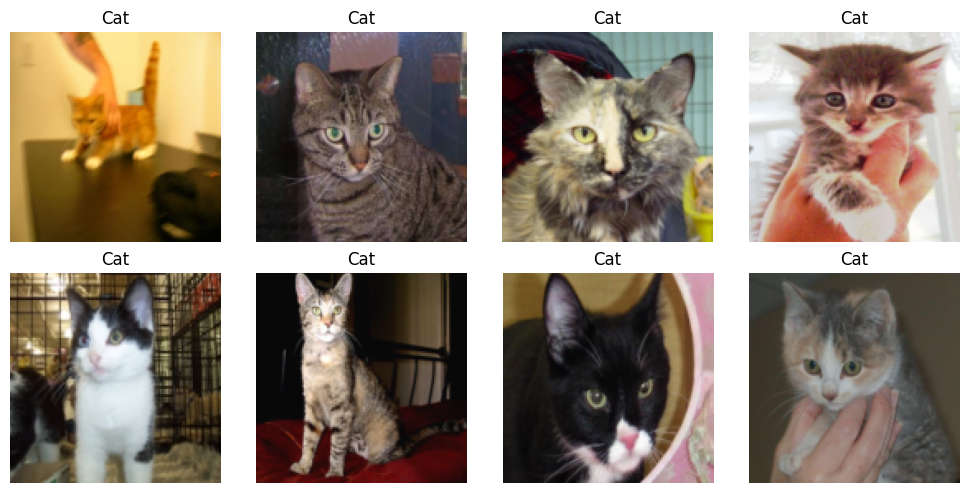

Kích thước ảnh sau resize: torch.Size([3, 128, 128])


In [6]:
if full_dataset is not None:
    plt.figure(figsize=(10, 5))

    for i in range(min(8, len(full_dataset))):
        image, label = full_dataset[i]
        plt.subplot(2, 4, i + 1)
        plt.imshow(image.permute(1, 2, 0))
        plt.title(classes[label])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    image, label = full_dataset[0]
    print("Kích thước ảnh sau resize:", image.shape)

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


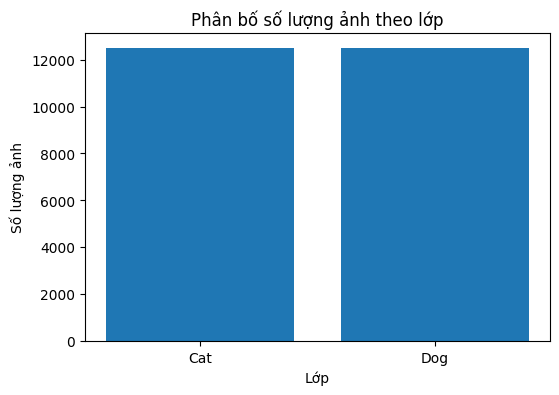

Cat: 12499 ảnh
Dog: 12499 ảnh


In [7]:
if full_dataset is not None:
    labels = [label for _, label in full_dataset]
    label_counts = Counter(labels)

    class_names = [classes[i] for i in range(len(classes))]
    counts = [label_counts[i] for i in range(len(classes))]

    plt.figure(figsize=(6, 4))
    plt.bar(class_names, counts)
    plt.title("Phân bố số lượng ảnh theo lớp")
    plt.xlabel("Lớp")
    plt.ylabel("Số lượng ảnh")
    plt.show()

    for name, count in zip(class_names, counts):
        print(f"{name}: {count} ảnh")

## 3. Chia tập train - validation - test

In [8]:
if full_dataset is not None:
    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    print("Train size:", len(train_dataset))
    print("Validation size:", len(val_dataset))
    print("Test size:", len(test_dataset))

Train size: 17498
Validation size: 3749
Test size: 3751


## 4. Tăng cường dữ liệu và cân bằng dữ liệu

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [10]:
# Tạo lại dataset với transform phù hợp cho từng tập
if os.path.exists(dataset_path):
    full_dataset_train = datasets.ImageFolder(root=dataset_path, transform=train_transform)
    full_dataset_eval = datasets.ImageFolder(root=dataset_path, transform=test_transform)

    train_indices = train_dataset.indices
    val_indices = val_dataset.indices
    test_indices = test_dataset.indices

    train_dataset = Subset(full_dataset_train, train_indices)
    val_dataset = Subset(full_dataset_eval, val_indices)
    test_dataset = Subset(full_dataset_eval, test_indices)

# Đếm số lượng nhãn trong tập train để cân bằng dữ liệu
    train_labels = [full_dataset_eval.samples[i][1] for i in train_indices]
    class_count = np.bincount(train_labels)
    class_weights = 1.0 / class_count
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    print("Số lượng ảnh từng lớp trong train:", class_count)

Số lượng ảnh từng lớp trong train: [8777 8721]


In [11]:
batch_size = 32

if os.path.exists(dataset_path):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print("Số batch train:", len(train_loader))
    print("Số batch validation:", len(val_loader))
    print("Số batch test:", len(test_loader))

Số batch train: 274
Số batch validation: 59
Số batch test: 59


## 5. Xây dựng mô hình CNN thuần

In [12]:
class CatDog_CNN(nn.Module):
    def __init__(self):
        super(CatDog_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 6. Khởi tạo mô hình

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CatDog_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)
print("Thiết bị đang dùng:", device)

CatDog_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)
Thiết bị đang dùng: cpu


## 7. Huấn luyện mô hình

In [14]:
num_epochs = 15
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience = 3
trigger_times = 0
best_model_path = 'best_catdog_cnn.pth'

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Dừng sớm để tránh overfitting.")
            break

Epoch [1/15] - Train Loss: 0.6615 - Train Acc: 58.47% - Val Loss: 0.5974 - Val Acc: 67.38%
Epoch [2/15] - Train Loss: 0.5715 - Train Acc: 70.41% - Val Loss: 0.5108 - Val Acc: 74.82%
Epoch [3/15] - Train Loss: 0.5154 - Train Acc: 74.33% - Val Loss: 0.4788 - Val Acc: 77.22%
Epoch [4/15] - Train Loss: 0.4811 - Train Acc: 76.85% - Val Loss: 0.4431 - Val Acc: 79.46%
Epoch [5/15] - Train Loss: 0.4424 - Train Acc: 79.41% - Val Loss: 0.4221 - Val Acc: 80.79%
Epoch [6/15] - Train Loss: 0.4054 - Train Acc: 81.59% - Val Loss: 0.4607 - Val Acc: 78.05%
Epoch [7/15] - Train Loss: 0.3950 - Train Acc: 82.42% - Val Loss: 0.3687 - Val Acc: 83.33%
Epoch [8/15] - Train Loss: 0.3625 - Train Acc: 84.08% - Val Loss: 0.3769 - Val Acc: 82.82%
Epoch [9/15] - Train Loss: 0.3539 - Train Acc: 84.34% - Val Loss: 0.3394 - Val Acc: 85.17%
Epoch [10/15] - Train Loss: 0.3281 - Train Acc: 86.10% - Val Loss: 0.3380 - Val Acc: 86.02%
Epoch [11/15] - Train Loss: 0.3160 - Train Acc: 86.32% - Val Loss: 0.3529 - Val Acc: 84.5

## 8. Vẽ biểu đồ loss và accuracy

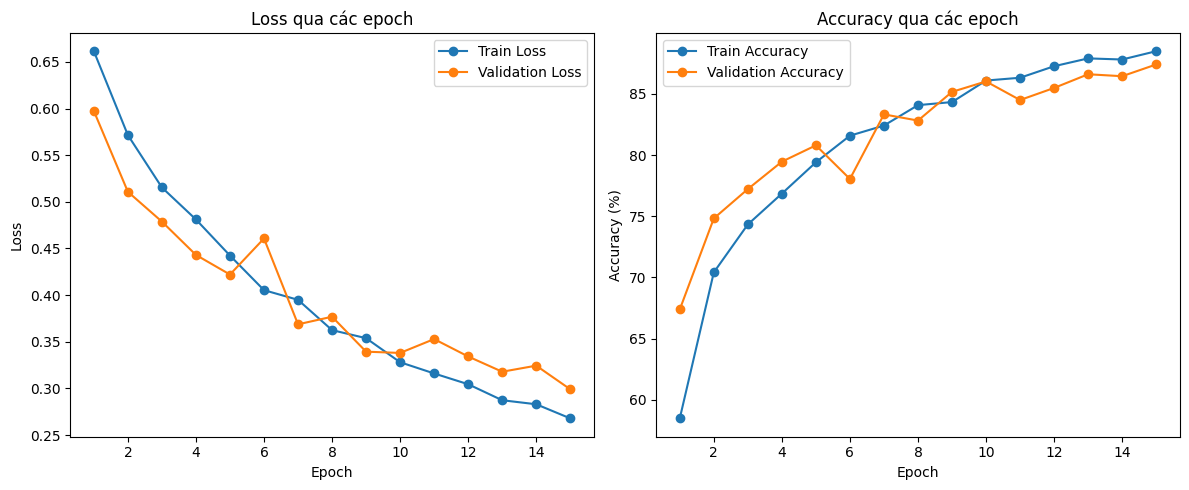

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.title("Loss qua các epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.title("Accuracy qua các epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Đánh giá mô hình trên tập test

In [16]:
# Nạp lại mô hình tốt nhất
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))

model.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Độ chính xác trên tập test: {test_accuracy:.2f}%")

Độ chính xác trên tập test: 87.90%


In [17]:
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

         Cat       0.87      0.89      0.88      1888
         Dog       0.89      0.87      0.88      1863

    accuracy                           0.88      3751
   macro avg       0.88      0.88      0.88      3751
weighted avg       0.88      0.88      0.88      3751



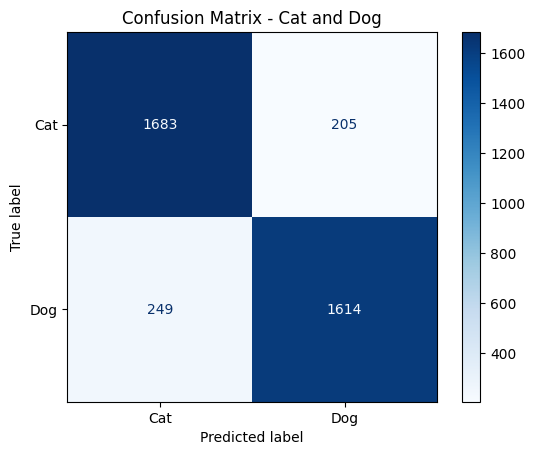

In [18]:
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Cat and Dog")
plt.show()

## 10. Trực quan kết quả dự đoán

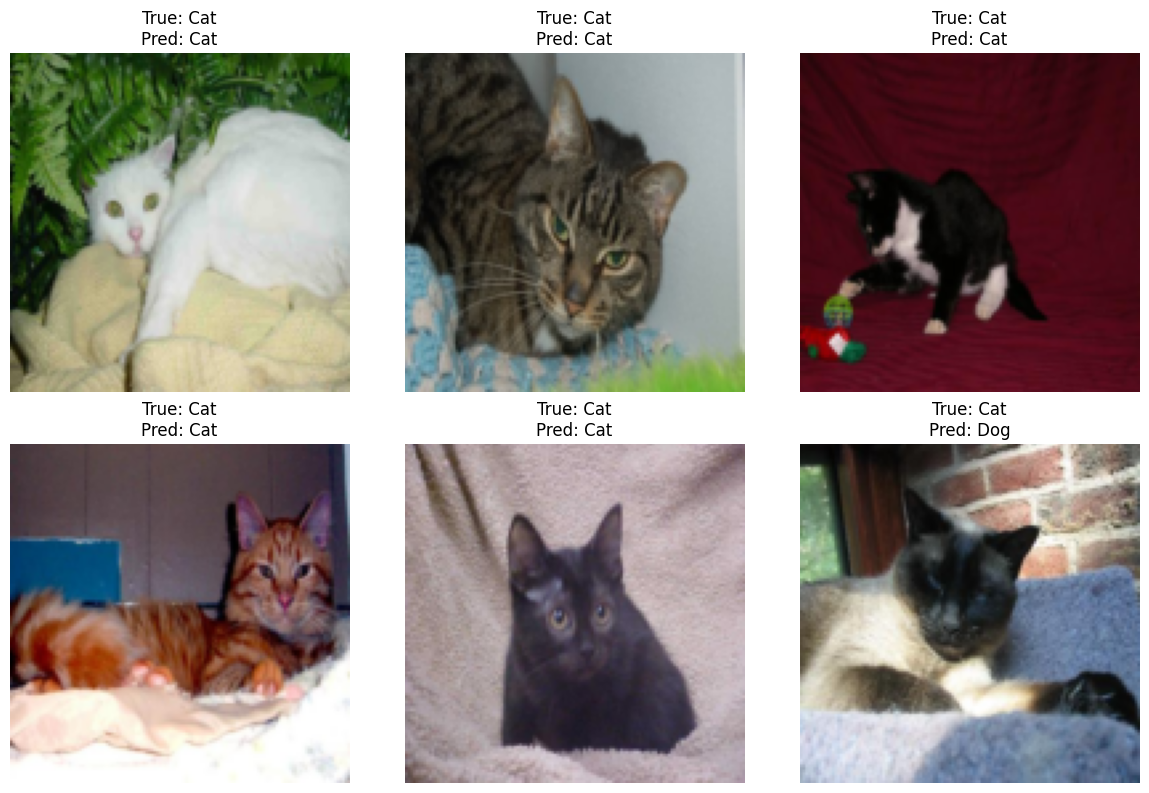

In [19]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

def visualize_prediction():
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()

    plt.figure(figsize=(12, 8))
    for i in range(min(6, len(images))):
        plt.subplot(2, 3, i + 1)
        imshow(images[i])
        plt.title(f"True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}")
    plt.tight_layout()
    plt.show()

visualize_prediction()

## 11. Trực quan feature map

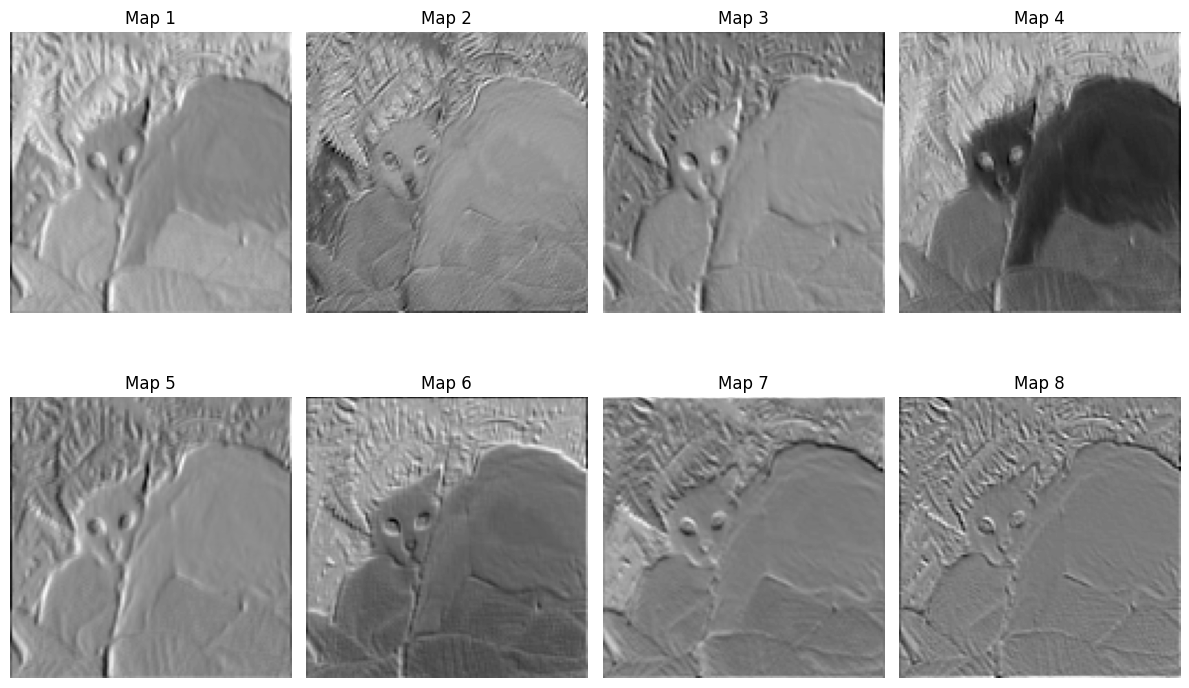

In [20]:
def visualize_feature_map():
    model.eval()
    images, _ = next(iter(test_loader))
    image = images[0].unsqueeze(0).to(device)

    with torch.no_grad():
        feature_maps = model.features[0](image)

    feature_maps = feature_maps.cpu().squeeze(0)

    plt.figure(figsize=(12, 8))
    for i in range(min(8, feature_maps.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(feature_maps[i], cmap='gray')
        plt.axis('off')
        plt.title(f"Map {i+1}")
    plt.tight_layout()
    plt.show()

visualize_feature_map()

## Nhận xét:

Bộ dữ liệu Cat and Dog là bài toán phân loại nhị phân với cấu trúc dữ liệu rõ ràng (2 lớp: cat và dog), số lượng ảnh lớn (~12.000 ảnh) và đặc trưng hình ảnh tương đối dễ phân biệt.

Trong quá trình huấn luyện, mô hình CNN cho thấy sự hội tụ nhanh với train accuracy và validation accuracy tăng ổn định qua từng epoch. Kết quả đạt được độ chính xác trên tập kiểm tra khoảng 90.19%, chứng tỏ mô hình học tốt và có khả năng tổng quát hóa cao.

Việc sử dụng các kỹ thuật như data augmentation (flip, rotation), dropout và early stopping đã giúp giảm overfitting và cải thiện hiệu năng. Đây là dataset phù hợp để kiểm chứng hiệu quả của CNN thuần trong bài toán phân loại cơ bản.